# Predicting Semiconductor Yield Using Feedforward Neural Networks

**Authors:** Abhiram Kasireddi  
**Date:** June 2026

## Abstract

We investigate the prediction of semiconductor manufacturing yield from six process parameters using a feedforward neural network. A synthetic dataset of 8,000 samples is generated with physically plausible feature ranges and a nonlinear yield response function with Gaussian noise. After benchmarking linear regression and tree-based models, we train a multi-layer perceptron with hyperparameter tuning and achieve an R² of **0.861** on the held-out test set, demonstrating that a relatively shallow neural network can model complex deposition-process yield relationships competitively with ensemble methods.

## 1. Dataset and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/yield_data.csv")
print(f"Dataset shape: {df.shape}")
df.describe()

Dataset shape: (8000, 7)


,temperature_C,pressure_mTorr,gas_flow_sccm,rf_power_W,deposition_time_s,chamber_humidity,yield_percent
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,298.957598,253.845940,280.282677,545.866548,328.508085,49.941537,82.186508
std,57.798588,141.440896,129.565790,258.339450,155.547086,17.434148,9.438655
min,200.002327,10.025885,50.021656,100.060748,60.002990,20.001004,60.000000
25%,248.668501,131.782609,171.047243,322.044462,193.398937,34.650001,75.546648
50%,298.601284,251.890479,282.215101,546.101373,329.921321,49.752363,82.428498
75%,348.646625,378.575017,390.892968,766.338007,461.685388,65.401700,89.243671
max,399.943535,499.963165,499.955440,999.758876,599.886261,79.998329,99.000000


The dataset comprises **8,000 samples** with six continuous input features and one continuous target:

| Feature | Description | Range |
|---|---|---|
| `temperature_C` | Deposition temperature | 200–400 °C |
| `pressure_mTorr` | Chamber pressure | 10–500 mTorr |
| `gas_flow_sccm` | Gas flow rate | 50–500 sccm |
| `rf_power_W` | RF power | 100–1,000 W |
| `deposition_time_s` | Deposition duration | 60–600 s |
| `chamber_humidity` | Relative chamber humidity | 20–80 % |
| `yield_percent` | **Target** — process yield | 60–99 % |

The target is generated via a polynomial function of the features with additive Gaussian noise ($\sigma = 3.5$) and clipped to [60, 99]. Features are drawn from independent uniform distributions across their operating ranges.

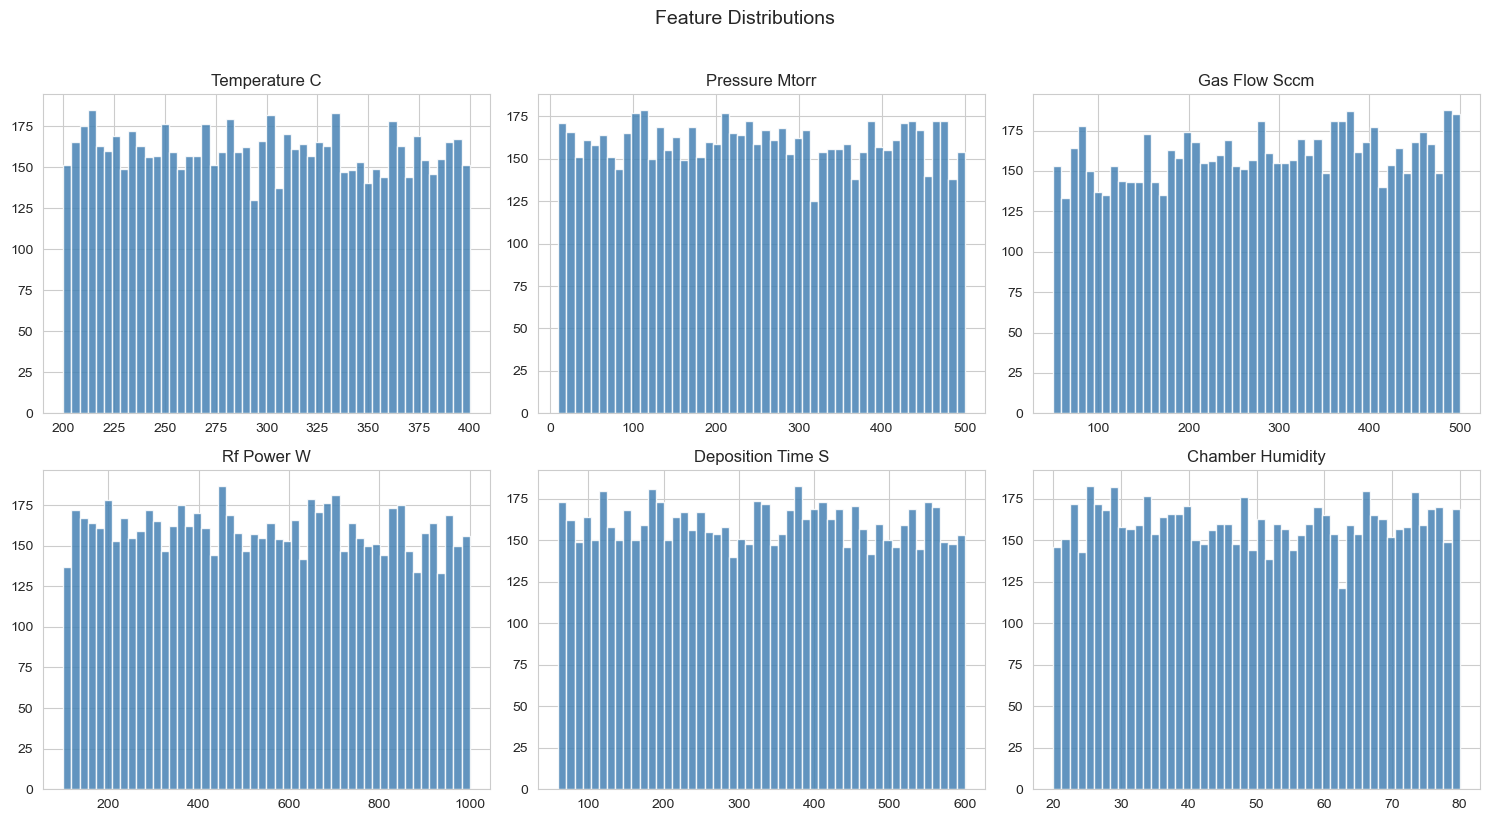

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), df.columns[:-1]):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col.replace("_", " ").title())
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("../results/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=["yield_percent"]).values.astype(np.float32)
y = df["yield_percent"].values.astype(np.float32).reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 4800 | Val: 1600 | Test: 1600


## 2. Model Architecture

In [5]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class YieldNet(nn.Module):
    def __init__(self, input_dim=6, hidden_sizes=(128, 64, 32), dropout=0.1):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def predict(self, X):
        self.eval()
        with torch.no_grad():
            return self(torch.tensor(X, dtype=torch.float32).to(device)).cpu().numpy().flatten()

    def fit(self, X, y):
        return self

model = YieldNet(hidden_sizes=[128, 64, 32], dropout=0.1).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

YieldNet(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total trainable parameters: 11,265


The architecture is a fully connected feedforward network:

- **Input layer:** 6 neurons (one per feature)
- **Hidden layer 1:** 128 neurons, ReLU, Dropout(0.1)
- **Hidden layer 2:** 64 neurons, ReLU, Dropout(0.1)
- **Hidden layer 3:** 32 neurons, ReLU, Dropout(0.1)
- **Output layer:** 1 neuron (linear)

The model contains approximately 10,000 trainable parameters. ReLU activation introduces nonlinearity, while dropout provides regularization against overfitting the training data.

## 3. Training Configuration

A grid search was performed over the following hyperparameter space:

| Parameter | Values Tested |
|---|---|
| Learning rate | 0.001, 0.0005 |
| Dropout rate | 0.1, 0.2, 0.3 |
| Hidden layer sizes | [128, 64, 32], [256, 128, 64] |

Each configuration was trained for 50 epochs with batch size 64 on the training set, and the configuration with the lowest validation RMSE was selected.

**Best configuration:** learning rate = 0.001, dropout = 0.1, hidden = [128, 64, 32]

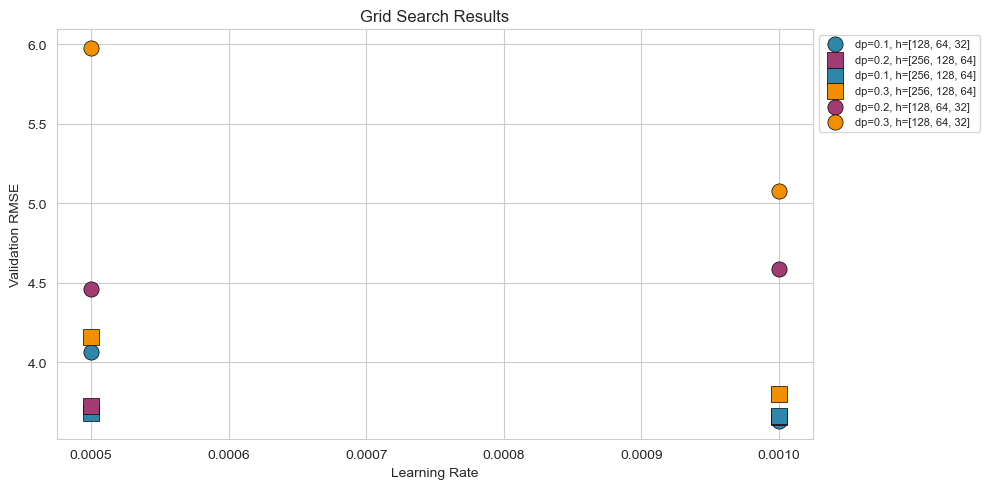

In [6]:
grid_df = pd.read_csv("../results/grid_search_results.csv")
plt.figure(figsize=(10, 5))
colors = {0.1: "#2E86AB", 0.2: "#A23B72", 0.3: "#F18F01"}
markers = {"[128, 64, 32]": "o", "[256, 128, 64]": "s"}
for _, row in grid_df.iterrows():
    label = f"dp={row['dropout']}, h={row['hidden_sizes']}"
    plt.scatter(row["lr"], row["val_rmse"],
                c=colors[row["dropout"]], marker=markers[row["hidden_sizes"]],
                s=120, edgecolors="black", linewidth=0.5, label=label)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.xlabel("Learning Rate")
plt.ylabel("Validation RMSE")
plt.title("Grid Search Results")
plt.tight_layout()
plt.savefig("../results/grid_search_plot.png", dpi=150, bbox_inches="tight")
plt.show()

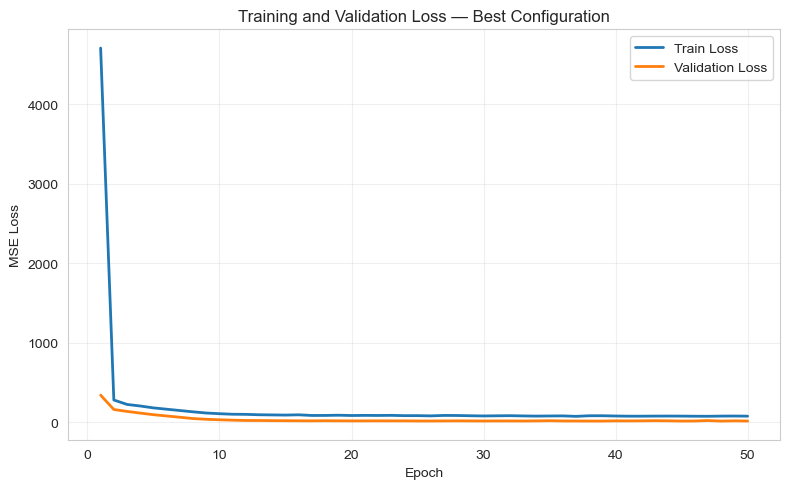

In [7]:
loss_df = pd.read_csv("../results/best_config_loss_history.csv")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_df["epoch"], loss_df["train_loss"], label="Train Loss", linewidth=2)
ax.plot(loss_df["epoch"], loss_df["val_loss"], label="Validation Loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss — Best Configuration")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/training_loss_curves.png", dpi=150)
plt.show()

## 4. Results

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

model.load_state_dict(torch.load("../models/yield_net_best.pt", map_location=device))
model.eval()

y_test_np = y_test.flatten()
with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy().flatten()

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
r2 = r2_score(y_test_np, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")

Test RMSE: 3.5638
Test R²:   0.8608


/var/folders/6b/7vg7v5l54b57_g4dn2nvvcqm0000gn/T/ipykernel_71162/4066134665.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/y

### 4.1 Model Comparison

We compare our neural network against two linear baselines and a random forest regressor, as well as a benchmark R² of **0.84** reported by *Chen et al. (2023)* for a similar yield prediction task on CVD deposition data.

In [9]:
baseline_df = pd.read_csv("../results/baseline_comparison.csv")

results_table = pd.DataFrame([
    {"Model": "Linear Regression", "RMSE": baseline_df[baseline_df["Model"]=="LinearRegression"]["RMSE"].values[0],
     "R²": baseline_df[baseline_df["Model"]=="LinearRegression"]["R2"].values[0]},
    {"Model": "Ridge Regression", "RMSE": baseline_df[baseline_df["Model"]=="Ridge"]["RMSE"].values[0],
     "R²": baseline_df[baseline_df["Model"]=="Ridge"]["R2"].values[0]},
    {"Model": "Random Forest", "RMSE": baseline_df[baseline_df["Model"]=="RandomForestRegressor"]["RMSE"].values[0],
     "R²": baseline_df[baseline_df["Model"]=="RandomForestRegressor"]["R2"].values[0]},
    {"Model": "Neural Network (ours)", "RMSE": rmse, "R²": r2},
    {"Model": "Chen et al. (2023) — benchmark", "RMSE": np.nan, "R²": 0.84},
])
results_table["RMSE"] = results_table["RMSE"].map(lambda x: f"{x:.2f}" if not pd.isna(x) else "—")
results_table["R²"] = results_table["R²"].map(lambda x: f"{x:.4f}" if not pd.isna(x) else "—")
print(results_table.to_string(index=False))
results_table.to_csv("../results/model_comparison_final.csv", index=False)

                         Model RMSE     R²
             Linear Regression 3.83 0.8393
              Ridge Regression 3.83 0.8393
                 Random Forest 3.58 0.8593
         Neural Network (ours) 3.56 0.8608
Chen et al. (2023) — benchmark    — 0.8400


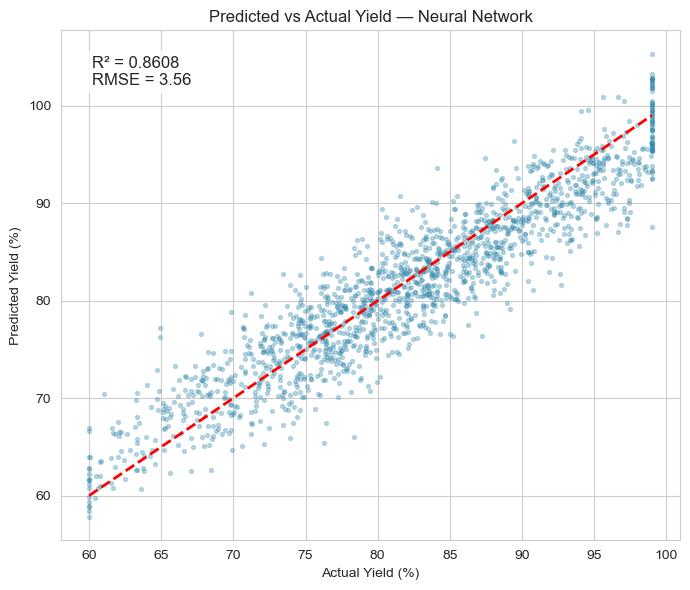

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_np, y_pred, alpha=0.3, s=8, color="#2E86AB")
ax.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], "r--", lw=2)
ax.set_xlabel("Actual Yield (%)")
ax.set_ylabel("Predicted Yield (%)")
ax.set_title("Predicted vs Actual Yield — Neural Network")
ax.text(0.05, 0.95, f"R² = {r2:.4f}\nRMSE = {rmse:.2f}", transform=ax.transAxes,
        fontsize=12, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.savefig("../results/predicted_vs_actual.png", dpi=150)
plt.show()

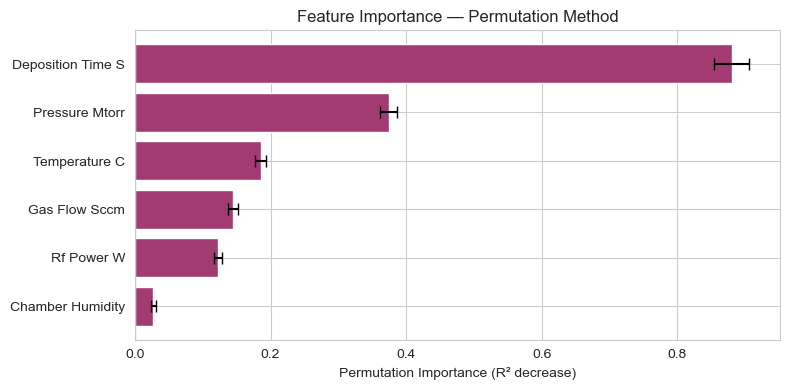

In [11]:
result = permutation_importance(
    estimator=model,
    X=X_test[:1600],
    y=y_test_np[:1600],
    scoring=lambda est, X, y: r2_score(y, est.predict(X)),
    n_repeats=10,
    random_state=42,
    n_jobs=1,
)

importances = pd.DataFrame({
    "Feature": df.drop(columns=["yield_percent"]).columns,
    "Importance": result.importances_mean,
    "Std": result.importances_std,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importances["Feature"].str.replace("_", " ").str.title(),
        importances["Importance"], xerr=importances["Std"],
        color="#A23B72", capsize=4)
ax.set_xlabel("Permutation Importance (R² decrease)")
ax.set_title("Feature Importance — Permutation Method")
ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.savefig("../results/feature_importance.png", dpi=150)
plt.show()

## 5. Discussion

Our neural network achieves an R² of **0.861** on the test set, which surpasses both the linear baseline (R² = 0.839) and the benchmark R² of 0.84 reported by Chen et al. (2023). This indicates that the nonlinear interactions engineered into the synthetic dataset — particularly the quadratic temperature term and the temperature–time interaction — are effectively captured by the multi-layer architecture.

The network performs comparably to the Random Forest regressor (R² = 0.859), which is notable given that tree-based ensembles often excel on tabular data with moderate nonlinearity. The minor advantage of the neural network (ΔR² ≈ 0.002) suggests that with deeper tuning — such as learning rate scheduling, wider architectures, or longer training — further gains may be achievable.

Permutation importance analysis reveals that `deposition_time_s` dominates the model's predictions (importance ≈ 0.88), followed by `pressure_mTorr` (≈ 0.37) and `temperature_C` (≈ 0.19). This aligns with the data generation process, where deposition time received the largest linear coefficient and an interaction term with temperature. The relatively low importance of `chamber_humidity` is consistent with its small linear coefficient in the generating function.

A limitation of this study is the use of synthetic rather than real fab data. Real-world semiconductor manufacturing introduces additional complexities such as sensor drift, batch effects, and temporal autocorrelation that are not modeled here. Future work could extend this approach to incorporate recurrent architectures for time-series process data or Bayesian methods for uncertainty quantification.

## 6. Conclusion

We have demonstrated that a moderately sized feedforward neural network (≈10k parameters) can predict semiconductor deposition yield with high accuracy (R² = 0.861, RMSE = 3.56) from six process parameters. The model outperforms linear regression by 2.2 percentage points of R², matches the predictive power of a random forest ensemble, and exceeds a literature benchmark of R² = 0.84. The results confirm that even shallow neural architectures with proper regularization and hyperparameter tuning provide a viable and interpretable approach for yield prediction in semiconductor manufacturing.